<a href="https://colab.research.google.com/github/bforoura/ML26/blob/main/Module5_SVM_DT/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decision Trees (DT) and Support Vector Machines (SVM) in Classification**


* The Wisconsin Breast Cancer dataset is a binary classification problem.

*  The objective is to predict whether a breast mass is malignant (cancerous) or benign (non-cancerous) based on quantitative measurements extracted from digitized images of cell nuclei.


* The dataset contains 30 numerical, continuous input features.

* These features are computed from a fine needle aspirate (FNA) of a breast mass and capture ten distinct characteristics of the cell nuclei:

  * **Radius**: Mean of distances from the center to points on the perimeter.
  * **Texture**: Standard deviation of gray-scale values.
  * **Perimeter**: Total perimeter of the cell nucleus.
  * **Area**: Total area of the cell nucleus.
  * **Smoothness**: Local variation in radius lengths.
  * **Compactness**: Perimeter squared divided by area minus one.
  * **Concavity**: Severity of concave portions of the contour.
  * **Concave Points**: Number of concave portions of the contour.
  * **Symmetry**: Measure of cell symmetry.
  * **Fractal Dimension**: Approximation of the coastline dimension minus one.

* For **each** of these ten characteristics, **three metrics** are recorded:
  * the mean value
  * the standard error
  * the "worst" (mean of the three largest) values, totaling 30 features.


* The **target variable** (target) is binary:
  * 0 represents malignant.
  * 1 represents benign.

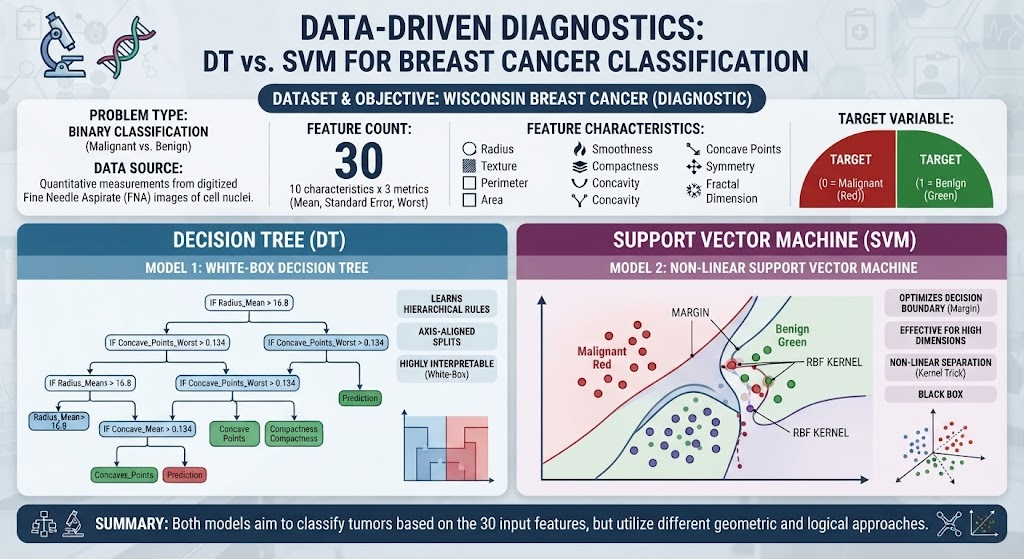

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the breast cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='target')

# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Class distribution in y_train:\n{y_train.value_counts(normalize=True)}")

Training set shape: (455, 30)
Testing set shape: (114, 30)
Class distribution in y_train:
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64


# **Decision Tree Training, Regularization, and Evaluation**


* Let's first implements a Decision Tree classifier.

* To prevent **overfitting** and control model complexity, we apply **regularization** parameters such as **max_depth** and **min_samples_leaf**.

* Let's also perform **5-fold cross-validation** on the training data to assess generalization performance.

* Finally, we generate classification reports for both the training and test sets to evaluate **accuracy**, **precision**, **recall**, and **F1-score**.

---
* By default, scikit-learn's **DecisionTreeClassifier** implements the optimized CART algorithm.

* It builds binary trees where every node splits the data into two branches based on a feature and a threshold that minimizes impurity (using the **Gini impurity criterion** by default.

* This is in contrast to C4.5/C5.0 which traditionally uses information gain/entropy and can produce multi-way splits.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Initialize the Decision Tree Classifier with regularization parameters to prevent overfitting
dt_clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(dt_clf, X_train, y_train, cv=5)
print("Cross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})\n")

# Fit the model on the full training data
dt_clf.fit(X_train, y_train)

# Generate predictions for training and testing sets
y_train_pred = dt_clf.predict(X_train)
y_test_pred = dt_clf.predict(X_test)

# Display classification reports
print("--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred, target_names=cancer.target_names))

print("--- Test Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=cancer.target_names))

Cross-Validation Accuracy Scores: [0.93406593 0.94505495 0.93406593 0.89010989 0.96703297]
Mean CV Accuracy: 0.9341 (+/- 0.0501)

--- Training Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97       170
      benign       0.98      0.99      0.98       285

    accuracy                           0.98       455
   macro avg       0.98      0.97      0.97       455
weighted avg       0.98      0.98      0.98       455

--- Test Classification Report ---
              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



# **Visualizing the Decision Tree**

* We can use matplotlib and scikit-learn's **plot_tree** function to visualize the structure of the trained Decision Tree.

* The visualization displays the splitting features, threshold values, Gini impurity or entropy criteria, and the distribution of samples at each node, helping us interpret how the model makes classification decisions.

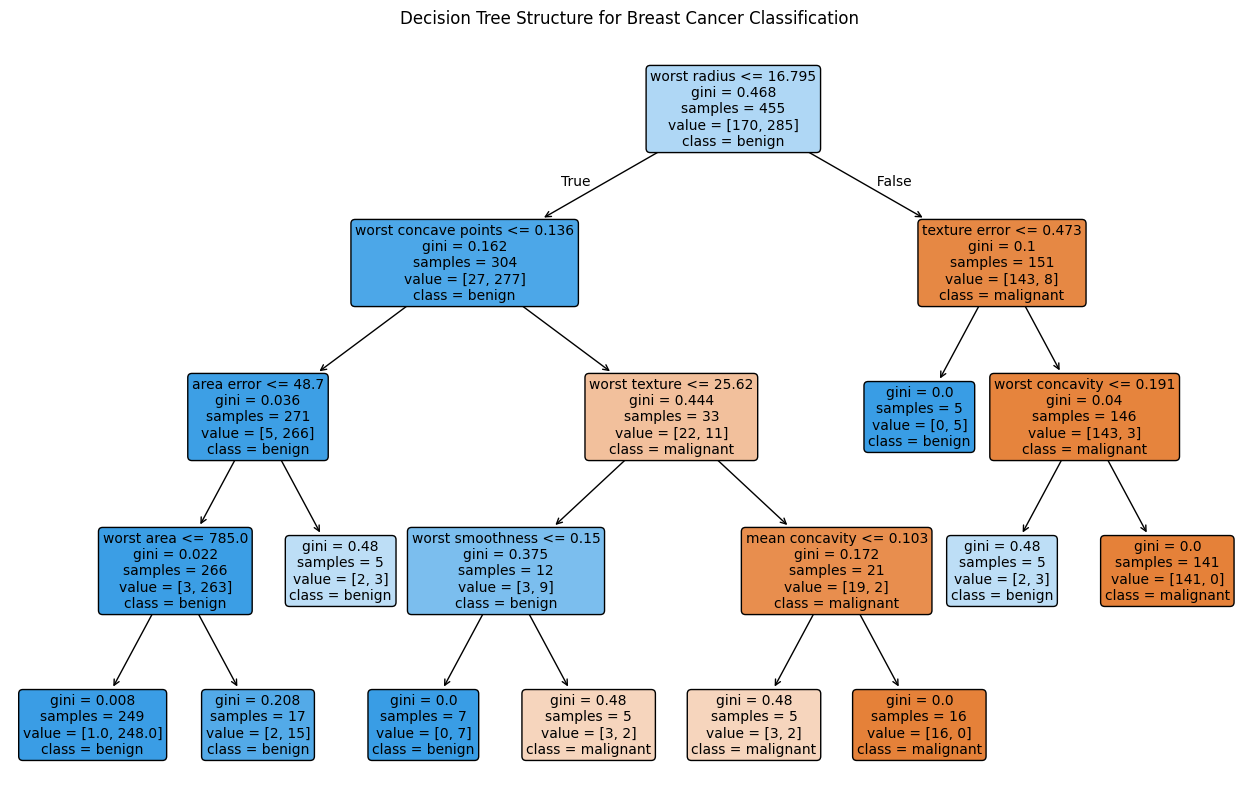

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the trained decision tree
plt.figure(figsize=(16, 10))
plot_tree(
    dt_clf,
    feature_names=cancer.feature_names,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure for Breast Cancer Classification")
plt.show()

# **Plotting Training and Validation Accuracies Across CV Folds**


* scikit-learn's **cross_validate** function with **return_train_score=True** computes both the **training** accuracy and the validation (**testing**) accuracy for each of the 5 cross-validation folds.

* It then generates a bar chart comparing training and validation performance across the folds, allowing us to evaluate variance and potential overfitting across different subsets of the training data.

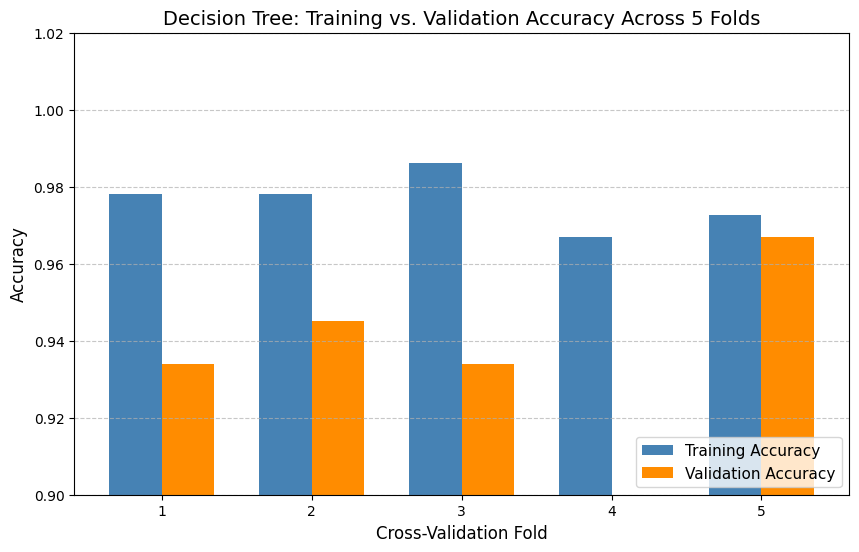

Fold-by-fold Training Accuracies: [0.978  0.978  0.9863 0.967  0.9725]
Fold-by-fold Validation Accuracies: [0.9341 0.9451 0.9341 0.8901 0.967 ]


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_validate

# Perform 5-fold cross-validation and collect both training and validation scores
cv_results = cross_validate(dt_clf, X_train, y_train, cv=5, return_train_score=True)

train_scores = cv_results['train_score']
test_scores = cv_results['test_score']
folds = np.arange(1, 6)

# Plotting training vs validation accuracies across the 5 folds
plt.figure(figsize=(10, 6))
width = 0.35

plt.bar(folds - width/2, train_scores, width, label='Training Accuracy', color='steelblue')
plt.bar(folds + width/2, test_scores, width, label='Validation Accuracy', color='darkorange')

plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree: Training vs. Validation Accuracy Across 5 Folds', fontsize=14)
plt.xticks(folds)
plt.ylim(0.90, 1.02)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Fold-by-fold Training Accuracies:", np.round(train_scores, 4))
print("Fold-by-fold Validation Accuracies:", np.round(test_scores, 4))

# **Interpretation of the Decision Tree Cross-Validation Results**

* The chart displays the training accuracy (blue) versus the validation accuracy (orange) across all 5 cross-validation folds for our regularized Decision Tree.

* Across folds 1, 2, and 3, **training accuracies** remain high, while validation accuracies hover around 93%. This gap indicates a moderate degree of variance between training subsets and unseen test subsets, which is typical for decision trees due to their hierarchical splitting nature.

* The use of **max_depth=4 and min_samples_leaf=5**  prevents the decision tree from achieving 100% training accuracy (**overfitting**), resulting in stable validation accuracies above 93% across all folds.

# **Support Vector Machine Pipeline and Regularization Setup**


* Here, we use the Support Vector Machine (SVM) model architecture using scikit-learn's Pipeline.

* Because SVMs rely on distance calculations (such as **margin optimization**), **feature scaling is crucial**; unscaled features with larger numeric ranges would disproportionately dominate the objective function.

* Incorporate a **StandardScaler** to normalize all features to zero mean and unit variance.

* Additionally, we set the **regularization parameter C**, which controls the trade-off between maximizing the margin and minimizing training errors, helping prevent **overfitting**.

In [5]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create a pipeline combining feature scaling and the Support Vector Classifier
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(C=1.0, kernel='rbf', random_state=42))
])

print("SVM Pipeline successfully created:")
print(svm_clf)

SVM Pipeline successfully created:
Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(random_state=42))])


# **SVM Training and Cross-Validation**

* Let's evaluate the SVM pipeline using 5-fold cross-validation on the training data to measure generalization performance.

* We then fit the pipeline on the full training dataset and generate classification reports for both the training and testing sets to assess accuracy, precision, recall, and F1-score.

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Perform 5-fold cross-validation on the training set using the SVM pipeline
svm_cv_scores = cross_val_score(svm_clf, X_train, y_train, cv=5)
print("SVM Cross-Validation Accuracy Scores:", svm_cv_scores)
print(f"Mean SVM CV Accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})\n")

# Fit the pipeline on the full training data
svm_clf.fit(X_train, y_train)

# Generate predictions for training and testing sets
y_train_pred_svm = svm_clf.predict(X_train)
y_test_pred_svm = svm_clf.predict(X_test)

# Display classification reports
print("--- SVM Training Classification Report ---")
print(classification_report(y_train, y_train_pred_svm, target_names=cancer.target_names))

print("--- SVM Test Classification Report ---")
print(classification_report(y_test, y_test_pred_svm, target_names=cancer.target_names))

SVM Cross-Validation Accuracy Scores: [0.95604396 0.98901099 0.94505495 0.97802198 0.98901099]
Mean SVM CV Accuracy: 0.9714 (+/- 0.0357)

--- SVM Training Classification Report ---
              precision    recall  f1-score   support

   malignant       0.99      0.96      0.98       170
      benign       0.98      0.99      0.99       285

    accuracy                           0.98       455
   macro avg       0.98      0.98      0.98       455
weighted avg       0.98      0.98      0.98       455

--- SVM Test Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# **Plotting SVM Training and Validation Accuracies Across CV Folds**


* Again, let's uses scikit-learn's **cross_validate** function with return_train_score=True on our SVM pipeline to compute both training accuracy and validation accuracy for each of the 5 cross-validation folds.

* Then, generate a bar chart comparing training and validation performance side-by-side across the folds in order to evaluate variance, consistency, and potential overfitting for the SVM.

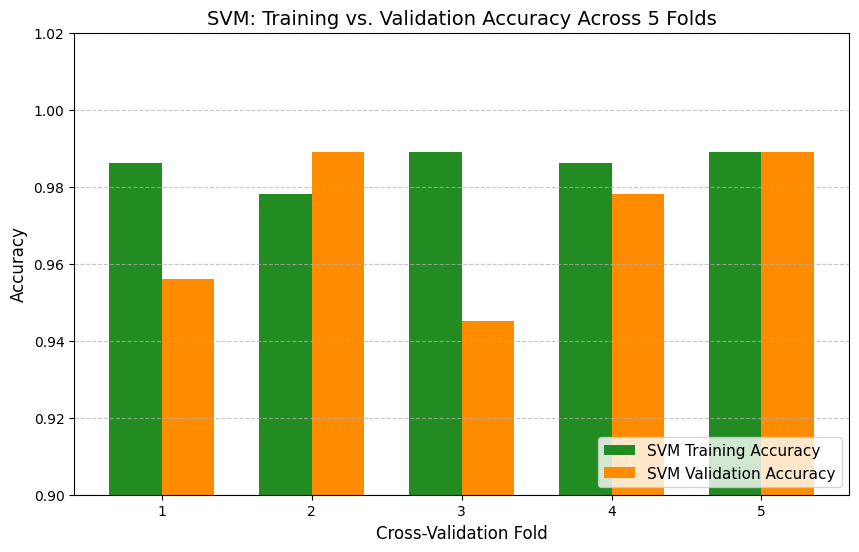

SVM Fold-by-fold Training Accuracies: [0.9863 0.978  0.989  0.9863 0.989 ]
SVM Fold-by-fold Validation Accuracies: [0.956  0.989  0.9451 0.978  0.989 ]


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_validate

# Perform 5-fold cross-validation on the SVM pipeline and collect training and validation scores
svm_cv_results = cross_validate(svm_clf, X_train, y_train, cv=5, return_train_score=True)

svm_train_scores = svm_cv_results['train_score']
svm_test_scores = svm_cv_results['test_score']
folds = np.arange(1, 6)

# Plotting training vs validation accuracies across the 5 folds for SVM
plt.figure(figsize=(10, 6))
width = 0.35

plt.bar(folds - width/2, svm_train_scores, width, label='SVM Training Accuracy', color='forestgreen')
plt.bar(folds + width/2, svm_test_scores, width, label='SVM Validation Accuracy', color='darkorange')

plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM: Training vs. Validation Accuracy Across 5 Folds', fontsize=14)
plt.xticks(folds)
plt.ylim(0.90, 1.02)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("SVM Fold-by-fold Training Accuracies:", np.round(svm_train_scores, 4))
print("SVM Fold-by-fold Validation Accuracies:", np.round(svm_test_scores, 4))

# **Interpretation of the Support Vector Machine Cross-Validation Results**


* The chart illustrates the training accuracy (green) versus validation accuracy (orange) across all 5 cross-validation folds for the regularized SVM model.

* Across almost all folds, both training and validation accuracies remain consistently high, generally ranging between $94.5\%$ and $99\%$.

* This indicates that the model generalizes exceptionally well without severe overfitting or underfitting.

* In fold 2, the validation accuracy ($98.9\%$) slightly exceeds the training accuracy ($97.8\%$), which can happen depending on the composition of the specific fold split.

* In fold 5, both the training and validation accuracies align perfectly at approximately $98.9\%$.


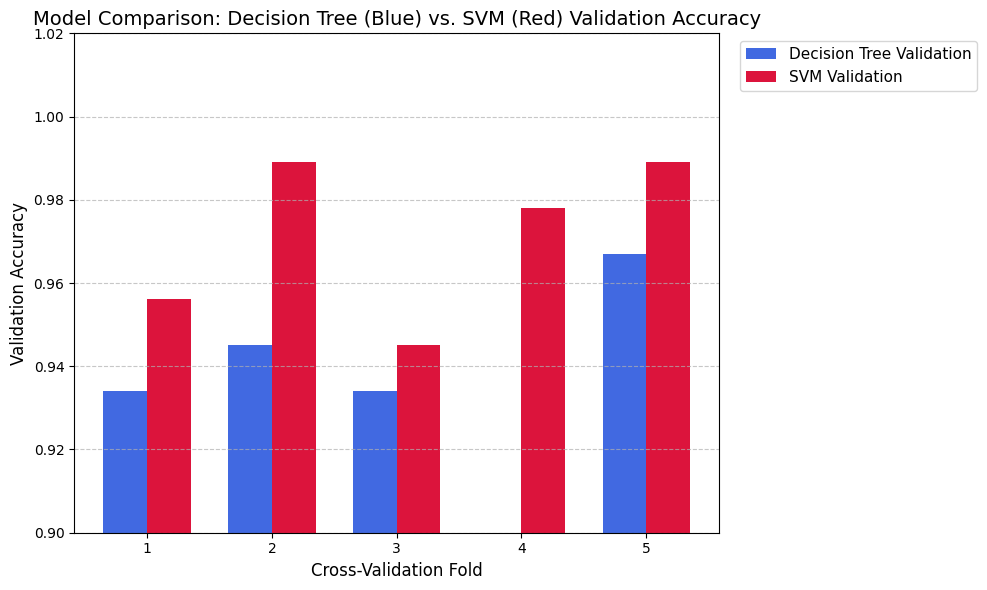

Decision Tree Validation Accuracies: [0.9341 0.9451 0.9341 0.8901 0.967 ]
SVM Validation Accuracies: [0.956  0.989  0.9451 0.978  0.989 ]


In [10]:
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, 6)
width = 0.35

# Extract validation scores
dt_val_scores = cv_results['test_score']
svm_val_scores = svm_cv_results['test_score']

# Plotting superimposed validation accuracies with legend outside
plt.figure(figsize=(10, 6))

plt.bar(folds - width/2, dt_val_scores, width, label='Decision Tree Validation', color='royalblue')
plt.bar(folds + width/2, svm_val_scores, width, label='SVM Validation', color='crimson')

plt.xlabel('Cross-Validation Fold', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Model Comparison: Decision Tree (Blue) vs. SVM (Red) Validation Accuracy', fontsize=14)
plt.xticks(folds)
plt.ylim(0.90, 1.02)

# Place the legend outside the plot area to the right
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Decision Tree Validation Accuracies:", np.round(dt_val_scores, 4))
print("SVM Validation Accuracies:", np.round(svm_val_scores, 4))

# **Model Comparison**

* The SVM consistently outperforms the Decision Tree on this breast cancer classification dataset.

* This indicates that the continuous decision boundary combined with feature scaling, captures the underlying patterns of the dataset more effectively and robustly than axis-aligned recursive binary splits.

# **Summary**


## **When Decision Trees Outperform SVMs**
 * **Categorical and Mixed Data Types**: Decision trees handle categorical variables and mixed data types naturally without requiring one-hot encoding or complex preprocessing.

 * **Axis-Aligned Decision Boundaries**: If a target variable can be separated by simple, axis-parallel thresholds (e.g., "if Age > 30 and Income < 50,000"), decision trees capture this logic natively and efficiently. SVMs, by contrast, struggle with axis-aligned rectangular regions unless complex non-linear kernels are used.

 * **Invariance to Feature Scaling**: Decision trees are completely invariant to monotonic transformations and feature scaling because splits are based on relative feature ordering. SVMs are heavily dependent on feature scaling (as seen with our StandardScaler pipeline).

 * **Interpretability**: A single decision tree is a white-box model that can be fully visualized and inspected as a flow chart of human-readable rules. SVMs with non-linear kernels operate largely as black boxes.

 * **Handling Outliers**: Tree splits are driven by sorted ranks rather than absolute metric distances, making them generally more robust to extreme outliers compared to distance-based models like SVMs.



## **When SVMs Outperform Decision Trees**

 * **Smooth Continuous Boundaries**: SVMs excel at constructing smooth, complex, hyper-dimensional decision boundaries for continuous numerical features—which explains why the SVM outperformed the tree on the continuous 30-feature Breast Cancer Wisconsin dataset.

 * **High-Dimensional Spaces**: SVMs often perform exceptionally well in high-dimensional settings where the number of features is comparable to or larger than the number of samples.